#IncodeVision
#Name of Student : Kalpesh Rajendra Patil

**Import Libraries**

In [ ]:
# (Usually already installed in Colab)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

**Dataset**

In [ ]:
data = {
    "CustomerID": list(range(1, 21)),
    "Age": [19,21,20,23,31,22,35,23,64,30,67,35,58,24,37,22,35,20,52,35],
    "Annual_Income": [15,15,16,16,17,17,18,18,19,19,20,20,21,21,22,22,23,23,24,24],
    "Spending_Score": [39,81,6,77,40,76,6,94,3,72,14,99,15,77,13,79,35,66,29,98]
}

df = pd.DataFrame(data)

df.head()

,CustomerID,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


**Select Features**

In [ ]:
X = df[['Age', 'Annual_Income', 'Spending_Score']]

**Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Elbow Method**

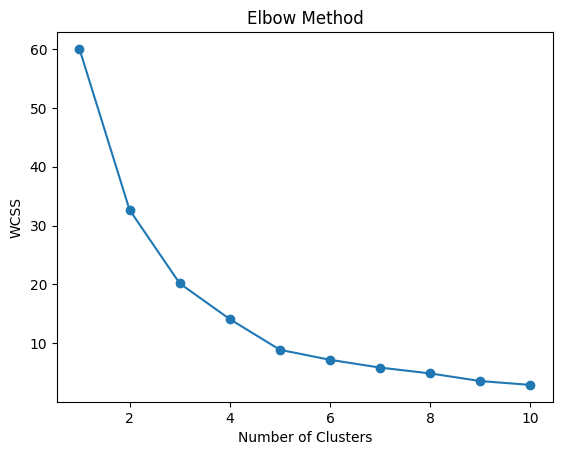

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

**Apply K-Means**

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Age,Annual_Income,Spending_Score,Cluster
0,1,19,15,39,0
1,2,21,15,81,3
2,3,20,16,6,0
3,4,23,16,77,3
4,5,31,17,40,0


**Visualization**

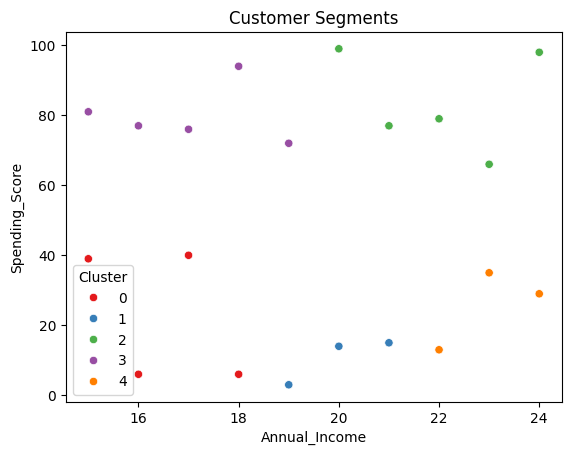

In [ ]:
plt.figure()
sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title("Customer Segments")
plt.show()

**Cluster Analysis**

In [ ]:
df.groupby('Cluster').mean()

,CustomerID,Age,Annual_Income,Spending_Score
Cluster,,,,
0,4.0,26.250000,16.5,22.750000
1,11.0,63.000000,20.0,10.666667
2,16.0,27.200000,22.0,83.800000
3,6.0,23.800000,17.0,80.000000
4,17.0,41.333333,23.0,25.666667


**3D Visualization**

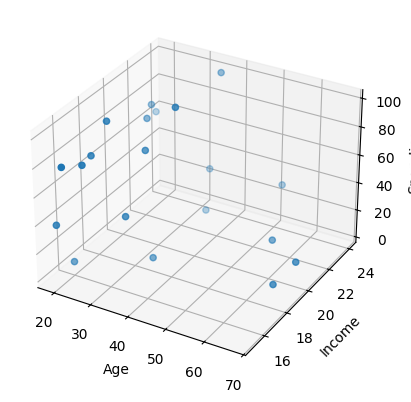

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Age'], df['Annual_Income'], df['Spending_Score'])

ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_zlabel("Spending")

plt.show()